Name :- Abhijeet Dinakar Pathade

Roll_No :- 16

Division :- A

# **Naive Bayes Classifier**

# Campus Message Detective — 3-Class Naive Bayes Classifier

### Mini Project Dataset
This version uses a **College CSV dataset from Google Drive** instead of embedding the messages directly in the notebook.

**Classes:** Academic | Placement | Promotional

**Algorithm:** Multinomial Naive Bayes  
**Text Vectorization:** CountVectorizer


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. Mount Google Drive

Run the cell below and allow Google Colab to access your Google Drive.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load the CSV Dataset from Google Drive

Place **`college_messages_222.csv`** directly inside **My Drive**.

Expected path:

`My Drive/college_messages_222.csv`

If you put it inside a folder, change `file_path` accordingly.

In [3]:
import pandas as pd

file_path = "/content/drive/MyDrive/college_messages.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (222, 2)


,message,label
0,Mega shopping sale starts today with exciting ...,Promotional
1,Shop now for exciting deals and special discou...,Promotional
2,The question bank for the upcoming examination...,Academic
3,Special festival sale is live with discounts u...,Promotional
4,Hurry! The biggest sale of the season ends ton...,Promotional


## 3. Inspect the Dataset

The CSV should contain two columns:

- `message` — the college message
- `label` — Academic, Placement, or Promotional

In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nTotal messages:", len(df))

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())


Column names:
['message', 'label']

Total messages: 222

Class distribution:
label
Promotional    74
Academic       74
Placement      74
Name: count, dtype: int64

Missing values:
message    0
label      0
dtype: int64


## 4. Display Sample Messages

In [ ]:
pd.set_option("display.max_colwidth", 150)

df.head(10)


,message,label
0,Mega shopping sale starts today with exciting discounts.,Promotional
1,Shop now for exciting deals and special discounts.,Promotional
2,The question bank for the upcoming examination has been uploaded to the LMS.,Academic
3,Special festival sale is live with discounts up to 80 percent.,Promotional
4,Hurry! The biggest sale of the season ends tonight.,Promotional
5,The placement cell has scheduled a coding practice test for tomorrow.,Placement
6,The company recruitment presentation will be held in the main auditorium.,Placement
7,The department has released the schedule for the practical examinations.,Academic
8,Students must verify their examination seat number on the portal.,Academic
9,The faculty has uploaded lecture slides for the next chapter.,Academic


## 5. Visualize Class Distribution

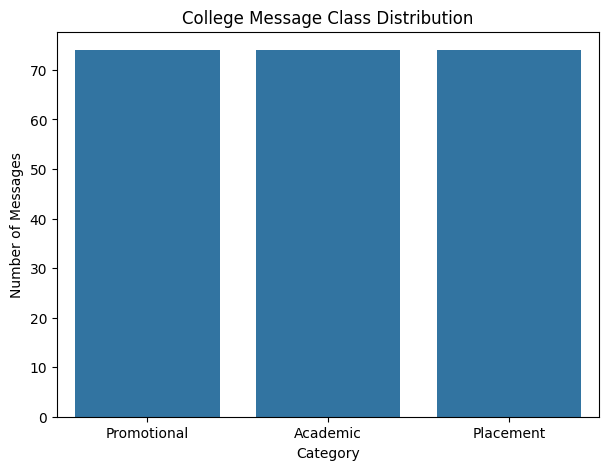

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="label")
plt.title("College Message Class Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Messages")
plt.show()


## 6. Prepare Features and Labels

In [ ]:
X = df["message"]
y = df["label"]

print("Features:", X.shape)
print("Labels:", y.shape)


Features: (222,)
Labels: (222,)


## 7. Split the Dataset into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))


Training messages: 166
Testing messages: 56


## 8. Convert Text into Numerical Features using CountVectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print("Training feature matrix:", X_train_vectorized.shape)
print("Testing feature matrix:", X_test_vectorized.shape)


Training feature matrix: (166, 374)
Testing feature matrix: (56, 374)


## 9. Train the Multinomial Naive Bayes Classifier

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

print("Model training completed successfully!")


Model training completed successfully!


## 10. Make Predictions

In [ ]:
y_pred = model.predict(X_test_vectorized)

print("Predictions:")
print(y_pred)


Predictions:
['Academic' 'Promotional' 'Academic' 'Placement' 'Promotional'
 'Promotional' 'Placement' 'Placement' 'Placement' 'Academic' 'Academic'
 'Promotional' 'Academic' 'Academic' 'Placement' 'Academic' 'Placement'
 'Placement' 'Promotional' 'Promotional' 'Promotional' 'Promotional'
 'Academic' 'Promotional' 'Placement' 'Academic' 'Academic' 'Promotional'
 'Placement' 'Placement' 'Promotional' 'Academic' 'Placement' 'Placement'
 'Placement' 'Promotional' 'Academic' 'Academic' 'Academic' 'Placement'
 'Promotional' 'Placement' 'Placement' 'Placement' 'Promotional'
 'Academic' 'Placement' 'Placement' 'Promotional' 'Promotional' 'Academic'
 'Academic' 'Promotional' 'Promotional' 'Promotional' 'Placement']


## 11. Evaluate the Model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 98.21 %

Classification Report:
              precision    recall  f1-score   support

    Academic       1.00      0.94      0.97        18
   Placement       0.95      1.00      0.97        19
 Promotional       1.00      1.00      1.00        19

    accuracy                           0.98        56
   macro avg       0.98      0.98      0.98        56
weighted avg       0.98      0.98      0.98        56



## 12. Confusion Matrix

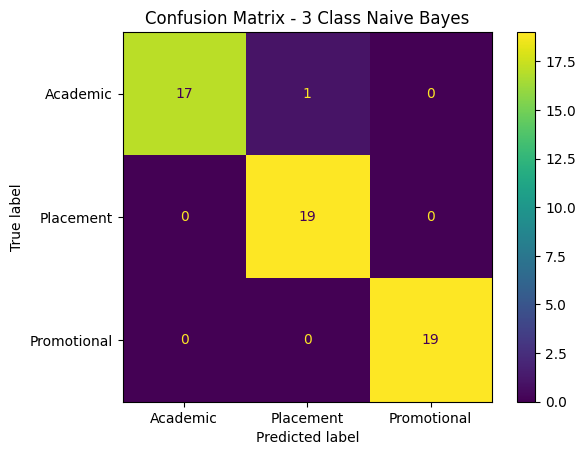

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix - 3 Class Naive Bayes")
plt.show()


## 13. Test the Classifier with New Messages

In [ ]:
test_messages = [
    "The DBMS practical examination will be conducted tomorrow in Lab 2.",
    "The placement cell has announced a campus recruitment drive for eligible students.",
    "Get 50 percent discount on selected products. Shop now and claim your offer."
]

test_vectors = vectorizer.transform(test_messages)
predictions = model.predict(test_vectors)

for message, prediction in zip(test_messages, predictions):
    print("Message:", message)
    print("Predicted Category:", prediction)
    print("-" * 80)


Message: The DBMS practical examination will be conducted tomorrow in Lab 2.
Predicted Category: Academic
--------------------------------------------------------------------------------
Message: The placement cell has announced a campus recruitment drive for eligible students.
Predicted Category: Placement
--------------------------------------------------------------------------------
Message: Get 50 percent discount on selected products. Shop now and claim your offer.
Predicted Category: Promotional
--------------------------------------------------------------------------------


## 14. Interactive Message Classification

In [ ]:
message = input("Enter a college message: ")

message_vector = vectorizer.transform([message])

prediction = model.predict(message_vector)[0]
probabilities = model.predict_proba(message_vector)[0]

print("\nPredicted Category:", prediction)

print("\nPrediction Probabilities:")
for class_name, probability in zip(model.classes_, probabilities):
    print(f"{class_name}: {probability * 100:.2f}%")


Enter a college message: Mega shopping sale starts today with exciting discounts.

Predicted Category: Promotional

Prediction Probabilities:
Academic: 0.01%
Placement: 0.01%
Promotional: 99.99%


## 15. Save the Trained Model and Vectorizer

These files will be used by the Flask application (`app2.py`).

In [ ]:
import joblib

joblib.dump(model, "naive_bayes_model2.pkl")
joblib.dump(vectorizer, "vectorizer2.pkl")

print("naive_bayes_model.pkl saved successfully!")
print("vectorizer.pkl saved successfully!")


naive_bayes_model.pkl saved successfully!
vectorizer.pkl saved successfully!


**Flask Code :-**

In [ ]:
from flask import Flask, render_template, request
import joblib


app = Flask(__name__)

# Load trained model and vectorizer
model = joblib.load("naive_bayes_model2.pkl")
vectorizer = joblib.load("vectorizer2.pkl")

# Sample college messages for dropdown
college_messages = [
    {
        "category": "Academic",
        "message": "The DBMS practical examination is scheduled for Tuesday in Lab 2."
    },
    {
        "category": "Academic",
        "message": "Students must submit the Machine Learning assignment before Friday."
    },
    {
        "category": "Academic",
        "message": "The semester examination timetable has been released on the college portal."
    },
    {
        "category": "Academic",
        "message": "The Data Science lecture has been shifted to Room 305."
    },

    {
        "category": "Placement",
        "message": "The placement cell has announced a campus recruitment drive for eligible students."
    },
    {
        "category": "Placement",
        "message": "Shortlisted students must report to the placement office tomorrow."
    },
    {
        "category": "Placement",
        "message": "The aptitude test for the campus placement will be conducted on Saturday."
    },
    {
        "category": "Placement",
        "message": "Eligible students must upload their resumes to the placement portal."
    },

    {
        "category": "Promotional",
        "message": "Exclusive student offer! Get 60 percent off on selected products."
    },
    {
        "category": "Promotional",
        "message": "Congratulations! Claim your special reward and free gift now."
    },
    {
        "category": "Promotional",
        "message": "Limited time discount available for students. Shop now."
    },
    {
        "category": "Promotional",
        "message": "Special sale today! Get exciting offers on your favorite products."
    }
]


@app.route("/", methods=["GET", "POST"])
def home():

    prediction = None
    message = ""
    selected_category = ""
    probabilities = None

    if request.method == "POST":

        selected_index = request.form.get("selected_message")
        custom_message = request.form.get("custom_message", "").strip()

        # Give priority to custom message
        if custom_message:
            message = custom_message
            selected_category = "Custom Message"

        # Otherwise use dropdown message
        elif selected_index:
            index = int(selected_index)

            if 0 <= index < len(college_messages):
                message = college_messages[index]["message"]
                selected_category = college_messages[index]["category"]

        # Make prediction
        if message:

            message_vector = vectorizer.transform([message])

            prediction = model.predict(message_vector)[0]

            probability_values = model.predict_proba(message_vector)[0]

            class_names = model.classes_

            probabilities = []

            for class_name, probability in zip(
                class_names,
                probability_values
            ):
                probabilities.append({
                    "class": class_name,
                    "probability": round(probability * 100, 2)
                })

    return render_template(
        "index2.html",
        messages=college_messages,
        prediction=prediction,
        message=message,
        selected_category=selected_category,
        probabilities=probabilities
    )


if __name__ == "__main__":
    app.run(debug=True)

**HTML Code :-**

In [ ]:
<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Campus Message Detective</title>

    <style>

        * {
            box-sizing: border-box;
            margin: 0;
            padding: 0;
        }

        body {
            font-family: Arial, sans-serif;
            background: #f4f7fb;
            color: #222;
        }

        header {
            background: #1e3a8a;
            color: white;
            text-align: center;
            padding: 30px 20px;
        }

        header h1 {
            font-size: 32px;
            margin-bottom: 8px;
        }

        header p {
            font-size: 16px;
            opacity: 0.9;
        }

        .container {
            width: 90%;
            max-width: 1050px;
            margin: 30px auto;
        }

        .card {
            background: white;
            border-radius: 12px;
            padding: 25px;
            margin-bottom: 25px;

            box-shadow:
                0 4px 12px rgba(0, 0, 0, 0.08);
        }

        h2 {
            margin-bottom: 18px;
            color: #1e3a8a;
        }

        /* Form */

        label {
            display: block;
            margin-bottom: 8px;
            font-weight: bold;
        }

        select,
        textarea {
            width: 100%;
            padding: 12px;
            border: 1px solid #ccc;
            border-radius: 7px;
            margin-bottom: 18px;
            font-size: 15px;
        }

        textarea {
            min-height: 110px;
            resize: vertical;
        }

        button {
            width: 100%;
            padding: 13px;

            background: #1e3a8a;
            color: white;

            border: none;
            border-radius: 7px;

            font-size: 16px;
            font-weight: bold;

            cursor: pointer;
        }

        button:hover {
            background: #172d6b;
        }

        .or {
            text-align: center;
            margin: 5px 0 18px;
            color: #777;
            font-weight: bold;
        }

        /* Result */

        .result {
            text-align: center;
        }

        .message-box {
            background: #f8fafc;
            padding: 15px;
            border-radius: 8px;
            margin-bottom: 20px;
            line-height: 1.6;
        }

        .prediction {
            display: inline-block;
            padding: 12px 25px;
            border-radius: 30px;
            color: white;
            font-size: 21px;
            font-weight: bold;
            margin: 10px 0 20px;
        }

        .academic {
            background: #16a34a;
        }

        .placement {
            background: #2563eb;
        }

        .promotional {
            background: #ea580c;
        }

        /* Probability */

        .probability-section {
            margin-top: 20px;
            text-align: left;
        }

        .probability-row {
            margin-bottom: 15px;
        }

        .probability-title {
            display: flex;
            justify-content: space-between;
            margin-bottom: 6px;
            font-weight: bold;
        }

        .bar-background {
            width: 100%;
            height: 16px;
            background: #e5e7eb;
            border-radius: 20px;
            overflow: hidden;
        }

        .bar {
            height: 100%;
            background: #1e3a8a;
            border-radius: 20px;
        }

        /* Message examples */

        .message-grid {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(250px, 1fr));
            gap: 15px;
        }

        .sample {
            background: #f8fafc;
            padding: 15px;
            border-radius: 8px;
            border-left: 5px solid #1e3a8a;
        }

        .sample h3 {
            margin-bottom: 8px;
            font-size: 15px;
        }

        .sample p {
            font-size: 14px;
            line-height: 1.5;
        }

        footer {
            text-align: center;
            padding: 25px;
            color: #666;
            font-size: 14px;
        }

        @media(max-width: 600px) {

            header h1 {
                font-size: 25px;
            }

            .container {
                width: 94%;
            }

            .card {
                padding: 18px;
            }

        }

    </style>
</head>


<body>

<header>

    <h1>🎓 Campus Message Detective</h1>

    <p>
        Three-Class College Message Classification
        using Multinomial Naive Bayes
    </p>

</header>


<div class="container">

    <!-- Classifier Form -->

    <div class="card">

        <h2>Classify a College Message</h2>

        <form method="POST">

            <label>
                Select a sample college message:
            </label>

            <select name="selected_message">

                <option value="">
                    -- Select a message --
                </option>

                {% for item in messages %}

                <option value="{{ loop.index0 }}">

                    [{{ item.category }}]
                    {{ item.message }}

                </option>

                {% endfor %}

            </select>


            <div class="or">
                OR
            </div>


            <label>
                Enter your own message:
            </label>

            <textarea
                name="custom_message"
                placeholder="Example: The campus placement aptitude test will be conducted tomorrow..."
            ></textarea>


            <button type="submit">
                 Classify Message
            </button>

        </form>

    </div>


    <!-- Prediction Result -->

    {% if prediction %}

    <div class="card result">

        <h2>Prediction Result</h2>

        <div class="message-box">

            <strong>Message:</strong>

            <br>

            {{ message }}

        </div>


        <p>
            Predicted Category
        </p>


        {% if prediction == "Academic" %}

            <div class="prediction academic">
                📚 {{ prediction }}
            </div>

        {% elif prediction == "Placement" %}

            <div class="prediction placement">
                💼 {{ prediction }}
            </div>

        {% else %}

            <div class="prediction promotional">
                🛍️ {{ prediction }}
            </div>

        {% endif %}


        {% if probabilities %}

        <div class="probability-section">

            <h2>
                Prediction Probabilities
            </h2>


            {% for item in probabilities %}

            <div class="probability-row">

                <div class="probability-title">

                    <span>
                        {{ item.class }}
                    </span>

                    <span>
                        {{ item.probability }}%
                    </span>

                </div>


                <div class="bar-background">

                    <div
                        class="bar"
                        data-width="{{ item.probability }}">
                    </div>

                </div>

            </div>

            {% endfor %}

        </div>

        {% endif %}

    </div>

    {% endif %}


    <!-- Sample Messages -->

    <div class="card">

        <h2>College Message Examples</h2>

        <div class="message-grid">

            {% for item in messages %}

            <div class="sample">

                <h3>
                    {{ item.category }}
                </h3>

                <p>
                    {{ item.message }}
                </p>

            </div>

            {% endfor %}

        </div>

    </div>

</div>


<footer>

    Campus Message Detective |
    222 Synthetic College Messages |
    Multinomial Naive Bayes

</footer>
<script>
    document.querySelectorAll(".bar").forEach(function(bar) {
        const width = bar.getAttribute("data-width");
        bar.style.width = width + "%";
    });
</script>

</body>
</html>


</body>
</html>